# Notebook 2: Clean and Organise Dataset

## 1. Setup

Install required packages and import libraries.

In [1]:
import numpy as np
import os
import pandas as pd
import textstat
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


## 2. Load Dataset

In [2]:
#Read the CSV file to check if it was created correctly
df= pd.read_csv("../preprocessing_data/raw_texts_all_levels_with_smog_and_flesch_kincaid_scores.csv")
df.head()

,cefr_folder,title,cefr_age_group,text,flesch_kincaid_score,smog_score
0,A1,airplane,6-8,"We are taking off, Margaret.\nWow. We are goin...",1.573182,5.985473
1,A1,alphabet_song,6-8,Do you know the Alphabet song?\nThe alphabet s...,2.347147,7.168622
2,A1,always_eating,6-8,Jane called Lisa. Lisa said she was eating. Sh...,0.980698,3.129100
3,A1,angry_parent,6-8,You need to try harder in school!\nI am doing ...,2.603886,6.427356
4,A1,animal_shelter,6-8,Today we go to the dog pound.\nWhat's that dad...,0.505119,3.129100


## 3. Handle Duplicate Texts

Two identical texts were found under different CEFR labels. I haven't dropped anything here, because they are in different folders so have no immediate impact on each other. These are re evaluated further down after data manipulation and cleaning


In [3]:
# Check for empty texts
empty_texts = df[df["text"].str.strip() == ""]
print(f"Empty texts found: {len(empty_texts)}")

# Check for duplicate texts
duplicate_texts = df[df.duplicated(subset=["text"], keep=False)]
print(f"Duplicate texts found: {len(duplicate_texts)}")
print(duplicate_texts[["text", "cefr_age_group", ]].head(10))


Empty texts found: 0
Duplicate texts found: 2
                                                  text cefr_age_group
82   She used to eat meat. She used to eat a lot of...            6-8
705  She used to eat meat. She used to eat a lot of...          10-12


## 4. Estimate UK Reading Age from FK Score


In [4]:
def fk_to_numeric_age(fk):
    return round(fk + 5)

def age_to_reading_band(age):
    if age <= 5:
        return "≤5"
    elif age <= 7:
        return "6-7"
    elif age <= 12:
        return "8-12"
    elif age <= 14:
        return "13-14"
    elif age <= 16:
        return "15-16"
    elif age <= 18:
        return "17-18"
    else:
        return ">18"


## 5. Assign Reading Bands

In [5]:
df["fk_estimated_uk_age_num"] = df["flesch_kincaid_score"].apply(fk_to_numeric_age)
df["reading_band"] = df["fk_estimated_uk_age_num"].apply(age_to_reading_band)

## 6. Add Textstat Features

In [6]:
df["lexicon_count"] = df["text"].apply(textstat.lexicon_count)
df["sentence_count"] = df["text"].apply(textstat.sentence_count)
df["syllables_per_word"] = df["text"].apply(lambda t: textstat.syllable_count(t) / max(textstat.lexicon_count(t), 1))
df["polysyllable_count"] = df["text"].apply(textstat.polysyllabcount)
df["monosyllable_count"] = df["text"].apply(textstat.monosyllabcount)
df["flesch_reading_ease"] = df["text"].apply(textstat.flesch_reading_ease)
df["coleman_liau_index"] = df["text"].apply(textstat.coleman_liau_index)
df["automated_readability_index"] = df["text"].apply(textstat.automated_readability_index)
df["dale_chall_readability_score"] = df["text"].apply(textstat.dale_chall_readability_score)
df["difficult_words"] = df["text"].apply(textstat.difficult_words)
df["linsear_write_formula"] = df["text"].apply(textstat.linsear_write_formula)
df["gunning_fog"] = df["text"].apply(textstat.gunning_fog)
df["text_standard"] = df["text"].apply(textstat.text_standard)
df["spache_readability"] = df["text"].apply(textstat.spache_readability)
df["reading_time"] = df["text"].apply(textstat.reading_time)







In [7]:
print(f"Final row count before removing duplicates: {len(df)}")

Final row count before removing duplicates: 1493


## 7. Clean (Empty & Duplicate Checks)

Two identical texts were found under different CEFR labels. These were saved to `duplicates_review.csv` for reference and one version was removed to avoid duplication in the final dataset.

It was removed here and not earlier because before they were in separate groups whereas now all data has been aligned with a flesch kincaid score, they have the same grouping and so one is not needed.

In [8]:
# Check for empty texts
empty_texts = df[df["text"].str.strip() == ""]
print(f"Empty texts found: {len(empty_texts)}")

# Check for duplicate texts
duplicate_texts = df[df.duplicated(subset=["text"], keep=False)]
print(f"Duplicate texts found: {len(duplicate_texts)}")
print(duplicate_texts[["text", "cefr_age_group", "reading_band", ]].head(10))

Empty texts found: 0
Duplicate texts found: 2
                                                  text cefr_age_group  \
82   She used to eat meat. She used to eat a lot of...            6-8   
705  She used to eat meat. She used to eat a lot of...          10-12   

    reading_band  
82           6-7  
705          6-7  


In [9]:
os.makedirs("analysis_outputs", exist_ok=True)
duplicate_texts = df[df.duplicated(subset=["text"], keep=False)]
duplicate_texts.to_csv("analysis_outputs/duplicates_review.csv", index=False)


In [10]:
# 🧹 Drop all but the first occurrence of each duplicate
df = df.drop_duplicates(subset=["text"], keep="first").reset_index(drop=True)

print(f"Final cleaned dataset shape: {df.shape}")

Final cleaned dataset shape: (1492, 23)


In [11]:
print(f"Final row count after removing duplicates: {len(df)}")

Final row count after removing duplicates: 1492


In [12]:
# Print the number of texts in each age group
print(df["reading_band"].value_counts())

reading_band
8-12     357
15-16    298
6-7      258
13-14    226
17-18    170
>18      138
≤5        45
Name: count, dtype: int64


In [13]:
band_order = ["≤5", "6-7", "8-12", "13-14", "15-16", "17-18", ">18"]
df["reading_band"] = pd.Categorical(df["reading_band"], categories=band_order, ordered=True)

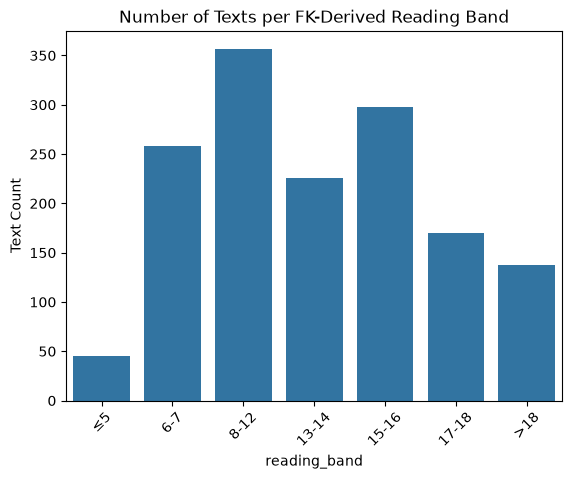

In [14]:
sns.countplot(data=df, x="reading_band", order=band_order)
plt.title("Number of Texts per FK-Derived Reading Band")
plt.xticks(rotation=45)
plt.ylabel("Text Count")
plt.show()

In [15]:
df.head()

,cefr_folder,title,cefr_age_group,text,flesch_kincaid_score,smog_score,fk_estimated_uk_age_num,reading_band,lexicon_count,sentence_count,...,flesch_reading_ease,coleman_liau_index,automated_readability_index,dale_chall_readability_score,difficult_words,linsear_write_formula,gunning_fog,text_standard,spache_readability,reading_time
0,A1,airplane,6-8,"We are taking off, Margaret.\nWow. We are goin...",1.573182,5.985473,7,6-7,44,8,...,93.579773,1.227273,1.444545,7.139073,6,2.000000,3.109091,1st and 2nd grade,2.982682,2.76172
1,A1,alphabet_song,6-8,Do you know the Alphabet song?\nThe alphabet s...,2.347147,7.168622,7,6-7,39,8,...,86.917644,1.179487,1.538269,6.307531,4,1.937500,6.052564,1st and 2nd grade,2.849452,2.49730
2,A1,always_eating,6-8,Jane called Lisa. Lisa said she was eating. Sh...,0.980698,3.129100,6,6-7,123,22,...,97.989496,1.775610,0.933016,9.433890,2,1.777778,2.236364,0th and 1st grade,3.305367,7.50659
3,A1,angry_parent,6-8,You need to try harder in school!\nI am doing ...,2.603886,6.427356,8,8-12,83,12,...,88.713379,3.819277,2.911225,7.023422,8,2.791667,3.730522,2nd and 3rd grade,2.954009,5.40592
4,A1,animal_shelter,6-8,Today we go to the dog pound.\nWhat's that dad...,0.505119,3.129100,6,6-7,42,8,...,100.791964,-1.414286,-0.974286,5.776662,3,1.625000,2.100000,0th and 1st grade,2.193536,2.33571


## 8. Save Final Cleaned Dataset


In [16]:
df.to_csv("../preprocessing_data/processed_texts_final.csv", index=False)

In [17]:
for band in df["reading_band"].unique():
    subset = df[df["reading_band"] == band]
    safe_band = str(band).replace(" ", "_").replace("≤", "less_than").replace(">", "over").replace(":", "")
    band_folder = f"../data/grouped_by_reading_band/{safe_band}"
    os.makedirs(band_folder, exist_ok=True)

    for _, row in subset.iterrows():
        with open(os.path.join(band_folder, row["title"] + ".txt"), "w", encoding="utf-8") as f:
            f.write(row["text"])

In [18]:
summary = df.groupby("reading_band").agg({
    "fk_estimated_uk_age_num": ["count", "mean"],
    "sentence_count": "mean"
}).round(2)

print(summary)

             fk_estimated_uk_age_num        sentence_count
                               count   mean           mean
reading_band                                              
≤5                                45   4.78          16.22
6-7                              258   6.45          15.09
8-12                             357  10.03          23.84
13-14                            226  13.56          27.49
15-16                            298  15.49          31.49
17-18                            170  17.49          29.60
>18                              138  20.34          24.81
